# 1- Importing and matching Data

- Get Parent directory from any location
- Import GEM xml file with original information
- Import firtered Compound Graph

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from pathlib import Path
from etc.parse_ids import XMLParser

# Get the notebook's directory and go up to project root
notebook_dir = Path().resolve()
project_root = notebook_dir.parent
data_folder = project_root / "data" / "resources"
Pilot = data_folder / "PilotStudy_All"

# Get graph prevouly fitered
graph_gml = data_folder / "generated" / "modified_graph.gml"
# Get the original graph for matching ids
human1_xml = data_folder / "Human-GEM.xml"

### Consortium sumarized data from different samples
- First we define a method to match the chebis with the HUMAN1
- Then upload data and apply changes

In [2]:
# Auxiliar function to extract the chebi number from a string like "CHEBI:12345"
def extract_single_chebi(value):
    """Extract CHEBI number from a single CHEBI string"""
    if pd.isna(value):
        return None
    match = re.search(r"CHEBI:(\d+)", str(value))
    if match:
        return int(match.group(1))
    return None

In [3]:
# Load the data file as a pandas DataFrame
data_file = pd.read_excel(Pilot / "Daniel_Suplementary_info.xlsx", sheet_name="Sheet1")

# Filter to only include rows where ID_level is 1
data_file = data_file[data_file.ID_level==1]

# Add new column with extracted CHEBI numbers
data_file['CHEBI_number'] = data_file.CHEBI_ID_Step2.apply(extract_single_chebi)

### From HUMAN1 GEM xml file 
- Create a dataframe
- Create colum to match chebis ids and link them with human1 ids

In [4]:
parser = XMLParser(human1_xml)
df = parser.extract_data()
df_human1 = parser.to_identifier_df()
df_human1['Consortium'] = None

### Matching and filling column

In [5]:
# Convert df_human1 CHEBI to integers for matching
df_human1['chebi_int'] = pd.to_numeric(df_human1['chebi'], errors='coerce').astype('Int64')
# Get set of CHEBIs from data_file
data_file_chebis = set(data_file['CHEBI_number'].dropna().values)

# Fill Consortium column with boolean: True if CHEBI matches, False otherwise
df_human1['Consortium'] = df_human1['chebi_int'].isin(data_file_chebis)

print(f"Consortium column filled with boolean values")
print(f"True matches: {df_human1['Consortium'].sum()}")
print(f"False (no match): {(~df_human1['Consortium']).sum()}")

Consortium column filled with boolean values
True matches: 356
False (no match): 8100


In [6]:
# Find CHEBIs in data_file that are NOT in df_human1
df_human1_chebis = set(df_human1['chebi_int'].dropna().values)
data_file_chebis_set = set(data_file['CHEBI_number'].dropna().values)

# CHEBIs not found in df_human1
unmatched_chebis = data_file_chebis_set - df_human1_chebis

print(f"Total CHEBIs in data_file: {len(data_file_chebis_set)}")
print(f"CHEBIs found in df_human1: {len(data_file_chebis_set - unmatched_chebis)}")
print(f"CHEBIs NOT found in df_human1: {len(unmatched_chebis)}")
print(f"\nUnmatched CHEBIs: {sorted(unmatched_chebis)}")

Total CHEBIs in data_file: 228
CHEBIs found in df_human1: 105
CHEBIs NOT found in df_human1: 123

Unmatched CHEBIs: [np.int64(4139), np.int64(4828), np.int64(9008), np.int64(11901), np.int64(14314), np.int64(15620), np.int64(15761), np.int64(16020), np.int64(16113), np.int64(16119), np.int64(16231), np.int64(16312), np.int64(16347), np.int64(16373), np.int64(16831), np.int64(17012), np.int64(17016), np.int64(17072), np.int64(17234), np.int64(17597), np.int64(17687), np.int64(17780), np.int64(18123), np.int64(19030), np.int64(19062), np.int64(19065), np.int64(19660), np.int64(21264), np.int64(21553), np.int64(21563), np.int64(21756), np.int64(21949), np.int64(25858), np.int64(27410), np.int64(27596), np.int64(27732), np.int64(27747), np.int64(27838), np.int64(28123), np.int64(28177), np.int64(28238), np.int64(28393), np.int64(28664), np.int64(28717), np.int64(28775), np.int64(28821), np.int64(28871), np.int64(28946), np.int64(30753), np.int64(30776), np.int64(30845), np.int64(35280), np

note: 123 metbolites from the data couldn't be match on HUMAN1, note some are lipis and most of them considered sidecompounds that will not be taken into account in the model. Also we only included level 1 annotated metabolites

### Mask to separate annotations 

In [7]:
capitainer = data_file[data_file.Capitainer == "Yes"]
mitra = data_file[data_file.Mitra == "Yes"]
whatman = data_file[data_file.Whatman == "Yes"]
blood = data_file[data_file.Blood == "Yes"]
plasma = data_file[data_file.Plasma == "Yes"]

### Mask separated annotations on HUMAN1 dataframe

In [8]:
devices = {
    "Capitainer": capitainer,
    "Mitra": mitra,
    "Whatman": whatman,
    "Blood": blood,
    "Plasma": plasma
}
for device_name, device_df in devices.items():
    chebis = set(device_df['CHEBI_number'].dropna().values)
    df_human1[device_name] = df_human1['chebi_int'].isin(device_df['CHEBI_number'].dropna().values)

    print(f"{device_name} column filled with boolean values")
    print(f"True matches: {df_human1[device_name].sum()}")
    print(f"False (no match): {(~df_human1[device_name]).sum()}")

Capitainer column filled with boolean values
True matches: 332
False (no match): 8124
Mitra column filled with boolean values
True matches: 338
False (no match): 8118
Whatman column filled with boolean values
True matches: 338
False (no match): 8118
Blood column filled with boolean values
True matches: 321
False (no match): 8135
Plasma column filled with boolean values
True matches: 330
False (no match): 8126


### Upsetplot

In [9]:
""" # Build the device sets from the HUMAN1 dataframe annotations
device_sets = {
    name: set(df_human1.loc[df_human1[name] == True].index.tolist())
    for name in devices.keys()
}
device_names = list(device_sets.keys())

# Compute exclusive intersections for all device combinations
intersection_counts = {}
for r in range(1, len(device_names) + 1):
    for combo in itertools.combinations(device_names, r):
        current = set.intersection(*(device_sets[name] for name in combo))
        for other_name in device_names:
            if other_name not in combo:
                current = current - device_sets[other_name]
        if current:
            intersection_counts[combo] = len(current)

# Keep the most relevant overlaps at the top
sorted_items = sorted(intersection_counts.items(), key=lambda item: item[1], reverse=True)
top_items = sorted_items[:15]

if top_items:
    combos, counts = zip(*top_items)
    labels = [' & '.join(combo) for combo in combos]
    fig, (ax_bar, ax_matrix) = plt.subplots(
        2, 1, figsize=(14, 8),
        gridspec_kw={'height_ratios': [3, 1]},
        constrained_layout=True
    )

    ax_bar.bar(range(len(counts)), counts, color='#2c7fb8', edgecolor='black')
    ax_bar.set_ylabel('Intersection size')
    ax_bar.set_title('UpSet Plot of Device Coincidences')
    ax_bar.set_xticks(range(len(labels)))
    ax_bar.set_xticklabels(labels, rotation=45, ha='right')

    ax_matrix.set_xlim(-0.5, len(counts) - 0.5)
    ax_matrix.set_ylim(-0.5, len(device_names) - 0.5)
    ax_matrix.set_yticks(range(len(device_names)))
    ax_matrix.set_yticklabels(device_names)
    ax_matrix.set_xticks(range(len(labels)))
    ax_matrix.set_xticklabels([])

    for x, combo in enumerate(combos):
        active_rows = [device_names.index(name) for name in combo]
        ax_matrix.scatter([x] * len(active_rows), active_rows, s=80, color='black')
        if len(active_rows) > 1:
            ax_matrix.plot([x, x], [min(active_rows), max(active_rows)], color='black', linewidth=1)

    for y in range(len(device_names)):
        ax_matrix.hlines(y, -0.5, len(counts) - 0.5, color='lightgray', linewidth=0.8)

    ax_matrix.invert_yaxis()
    ax_matrix.set_xlabel('Device intersections')
    ax_matrix.set_ylabel('Devices')
    ax_matrix.spines['top'].set_visible(False)
    ax_matrix.spines['right'].set_visible(False)
    ax_matrix.spines['left'].set_visible(False)

    plt.show()
else:
    print('No device coincidences found to plot.') """

" # Build the device sets from the HUMAN1 dataframe annotations\ndevice_sets = {\n    name: set(df_human1.loc[df_human1[name] == True].index.tolist())\n    for name in devices.keys()\n}\ndevice_names = list(device_sets.keys())\n\n# Compute exclusive intersections for all device combinations\nintersection_counts = {}\nfor r in range(1, len(device_names) + 1):\n    for combo in itertools.combinations(device_names, r):\n        current = set.intersection(*(device_sets[name] for name in combo))\n        for other_name in device_names:\n            if other_name not in combo:\n                current = current - device_sets[other_name]\n        if current:\n            intersection_counts[combo] = len(current)\n\n# Keep the most relevant overlaps at the top\nsorted_items = sorted(intersection_counts.items(), key=lambda item: item[1], reverse=True)\ntop_items = sorted_items[:15]\n\nif top_items:\n    combos, counts = zip(*top_items)\n    labels = [' & '.join(combo) for combo in combos]\n    

# 2- Model application
From here we will be using the graph  directly and showing results on the human1 graph

In [ ]:
import networkx as nx
from etc.hamiltonian import Hamiltonian
from etc.coverage import Coverage

### Define H object and parameters of G

In [ ]:
graph = nx.read_gml(graph_gml)
H = Hamiltonian(graph)
coverage = Coverage(H)
mu = H.mu_density_aware(graph)
gamma = H.gamma_balancer(mu=mu)
n = graph.number_of_nodes()

In [12]:
# Get all graph node labels
graph_nodes = list(graph.nodes())

# Create mapping of graph labels to indices
node_to_index = {node: idx for idx, node in enumerate(graph_nodes)}

In [13]:
# Create index lists for all devices (store selected node indices instead of binary masks)
device_indices = {}
device_energies = {}

for device_name in devices.keys():
    device_filtered = df_human1[df_human1[device_name] == True]
    device_ids = set(device_filtered.index.tolist())

    # Create list of node indices (0-based) present in device
    selected_indices = [node_to_index[node_id] for node_id in device_ids if node_id in node_to_index]
    device_indices[device_name] = selected_indices

In [14]:
S_cap =device_indices['Capitainer']
h_cap,t1_cap,t2_cap = H.compute(S_cap, mu=mu,gamma=gamma)

In [15]:
e = H.energy(S_cap, mu=mu, gamma=gamma)
e

182.43285111229483

In [ ]:
# Create index lists for all devices 
device_indices = {}
device_energies = {}

for device_name in devices.keys():
    device_filtered = df_human1[df_human1[device_name] == True]
    device_ids = set(device_filtered.index.tolist())

    # Create list of node indices (0-based) present in device
    selected_indices = [node_to_index[node_id] for node_id in device_ids if node_id in node_to_index]
    device_indices[device_name] = selected_indices
    # Compute Hamiltonian using list of indices
    h_val, t1, t2 = H.compute(selected_indices, mu=mu, gamma=gamma)
    # Store absolute total Hamiltonian (energy) as integer to match sampling outputs
    device_energies[device_name] = int(round(abs(h_val)))

    print(f"{device_name}: {len(selected_indices)} nodes, E = {device_energies[device_name]}")

Capitainer: 75 nodes, E = 182
Mitra: 77 nodes, E = 197
Whatman: 77 nodes, E = 197
Blood: 70 nodes, E = 145
Plasma: 73 nodes, E = 167


In [37]:
k = 75


random_node_indices = np.random.choice(n, size=k, replace=False)
random_node_indices = np.sort(random_node_indices)

random_node_indices

array([   5,   57,   78,  166,  271,  282,  301,  350,  396,  404,  480,
        516,  560,  597,  645,  691,  777,  781,  818,  832,  873,  908,
        947,  955, 1016, 1076, 1190, 1205, 1206, 1293, 1329, 1361, 1420,
       1432, 1446, 1477, 1492, 1563, 1628, 1656, 1682, 1798, 1817, 1854,
       1868, 1875, 1936, 1969, 1972, 2030, 2082, 2094, 2148, 2165, 2166,
       2281, 2304, 2345, 2403, 2418, 2450, 2535, 2549, 2632, 2646, 2787,
       2883, 2925, 3031, 3055, 3116, 3152, 3155, 3165, 3214])

In [38]:
H.compute(random_node_indices, mu=mu, gamma=gamma)

(255.49573244265633, -0.0, 255.49573244265633)

In [17]:
H.compute((device_indices['Capitainer']), mu=mu, gamma=gamma)

(182.43285111229483, -41.94193681177318, 224.37478792406802)

In [18]:
len(device_indices['Capitainer'])

75

### Energy distribution for variable k between the range of annotations

In [ ]:
variable_k_energy_samples, _, _ = coverage.sample_energy_variable_k(
    n=n, k_min=69, k_max=76, mu=mu, gamma=gamma, n_samples=80000
 )

### Energy distribution for Whatman

In [ ]:
energy_values_whatman, min_mask_whatman, max_mask_whatman = coverage.sample_energy(
    n=n, k=77, mu=mu, gamma=gamma, n_samples=80000
 )
h_values_whatman = energy_values_whatman.copy()
min_energy_whatman = np.where(min_mask_whatman == 1)[0]
max_energy_whatman = np.where(max_mask_whatman == 1)[0]

In [21]:
H.compute(max_energy_whatman, mu=mu, gamma=gamma)

(198.52597661590232, -4.993087715687283, 203.51906433158962)

In [22]:
H.energy(max_energy_whatman, mu=mu, gamma=gamma)

198.52597661590232

In [23]:
# min_ref_whatman = coverage.minimize_energy(S0=min_energy_whatman,n=n,steps=20000,
#                                            mu=mu, gamma=gamma)

### Energy distribution for Whole Blood

In [ ]:
energy_values_blood, min_mask_blood, max_mask_blood = coverage.sample_energy(
    n=n, k=70, mu=mu, gamma=gamma, n_samples=80000
 )
h_values_blood = energy_values_blood.copy()
min_energy_blood = np.where(min_mask_blood == 1)[0]
max_energy_blood = np.where(max_mask_blood == 1)[0]

### Energy distribution for Plasma

In [ ]:
energy_values_plasma, min_mask_plasma, max_mask_plasma = coverage.sample_energy(
    n=n, k=73, mu=mu, gamma=gamma, n_samples=80000
 )
h_values_plasma = energy_values_plasma.copy()
min_energy_plasma = np.where(min_mask_plasma == 1)[0]
max_energy_plasma = np.where(max_mask_plasma == 1)[0]

### Energy distribution for Mitra

In [ ]:
energy_values_mitra, min_mask_mitra, max_mask_mitra = coverage.sample_energy(
    n=n, k=77, mu=mu, gamma=gamma, n_samples=80000
 )
h_values_mitra = energy_values_mitra.copy()
min_energy_mitra = np.where(min_mask_mitra == 1)[0]
max_energy_mitra = np.where(max_mask_mitra == 1)[0]

### Energy distribution for Capitainer

In [ ]:
energy_values_capitainer, min_mask_capitainer, max_mask_capitainer = coverage.sample_energy(
    n=n, k=75, mu=mu, gamma=gamma, n_samples=80000
 )
h_values_capitainer = energy_values_capitainer.copy()
min_energy_capitainer = np.where(min_mask_capitainer == 1)[0]
max_energy_capitainer = np.where(max_mask_capitainer == 1)[0]

### Energy distribution intersection nodes

In [ ]:
energy_values_intersection, min_mask_intersection, max_mask_intersection = coverage.sample_energy(
    n=n, k=65, mu=mu, gamma=gamma, n_samples=80000
 )
h_values_intersection = energy_values_intersection.copy()
min_energy_intersection = np.where(min_mask_intersection == 1)[0]
max_energy_intersection = np.where(max_mask_intersection == 1)[0]

# 3- Visualization

### Combined Energy distribution for all devices
- Fro variable $k$ between the range of the observed nodes

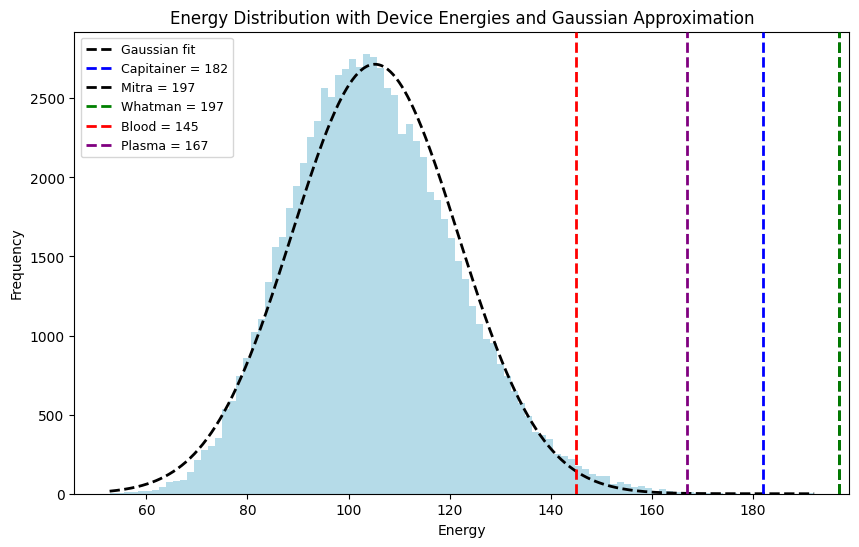

In [29]:
# Use sampled distribution from variable-k sampling
sampled_distribution = variable_k_energy_samples

# Compute histogram bins and counts for precise control
counts, bins = np.histogram(sampled_distribution, bins=100)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2

plt.figure(figsize=(10, 6))
# Light-blue bars with no contour
plt.bar(bin_centers, counts, width=bin_width, color='lightblue', edgecolor='none', align='center', alpha=0.9)

# Gaussian approximation (scaled to histogram counts)
sampled_mean = np.mean(sampled_distribution)
sampled_std = np.std(sampled_distribution)
x = np.linspace(bins[0], bins[-1], 500)
pdf = (1.0 / (sampled_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - sampled_mean) / sampled_std) ** 2)
pdf_scaled = pdf * len(sampled_distribution) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Colors for the five devices
colors = {
    'Capitainer': 'blue',
    'Mitra': 'black',
    'Whatman': 'green',
    'Blood': 'red',
    'Plasma': 'purple'
}

# Plot vertical lines for each device energy; emphasize Blood and Plasma
for name, color in colors.items():

    val = round(device_energies[name])

    plt.axvline(val, color=color, linestyle='--', linewidth=2, label=f'{name} = {val:.0f}', zorder=8)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy Distribution with Device Energies and Gaussian Approximation')
plt.legend(loc='upper left', fontsize=9)
plt.grid(False)
plt.savefig(f'{data_folder}/figs/energy_distribution_with_devices.png', dpi=400, bbox_inches='tight')
plt.show()

### Whatman device

Whatman energy samples: n=80000, mean=118.556317, median=117.707543, std=16.240742


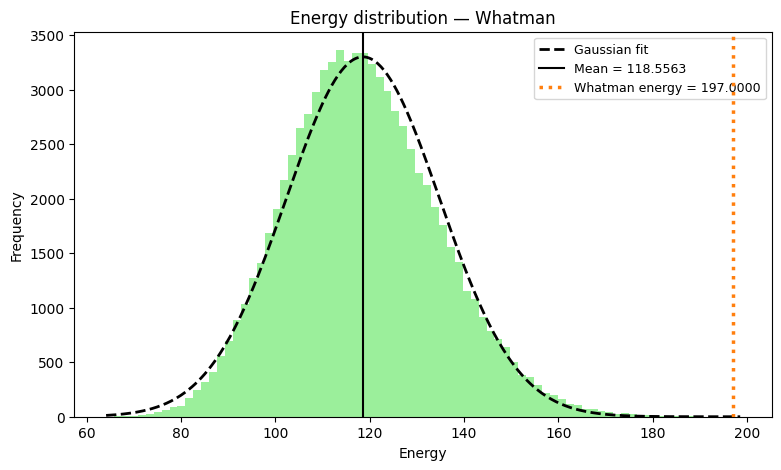

In [30]:
whatman_energy_samples = h_values_whatman
whatman_mean = np.mean(whatman_energy_samples)
whatman_median = np.median(whatman_energy_samples)
whatman_std = np.std(whatman_energy_samples)
whatman_min = np.min(whatman_energy_samples)
whatman_max = np.max(whatman_energy_samples)

print(f"Whatman energy samples: n={len(whatman_energy_samples)}, mean={whatman_mean:.6f}, median={whatman_median:.6f}, std={whatman_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(whatman_energy_samples, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='lightgreen', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (whatman_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - whatman_mean) / whatman_std) ** 2)
pdf_scaled = pdf * len(whatman_energy_samples) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(whatman_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {whatman_mean:.4f}')

# Plot device energy for Whatman (dotted line)
whatman_val = device_energies.get('Whatman')
plt.axvline(whatman_val, color='tab:orange', linestyle=':', linewidth=2.5, label=f"Whatman energy = {whatman_val:.4f}", zorder=9)
    

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Whatman')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_whatman.png', dpi=400, bbox_inches='tight')

plt.show()

### Whole Blood

Blood energy samples: n=80000, mean=97.951075, median=97.189208, std=14.096103


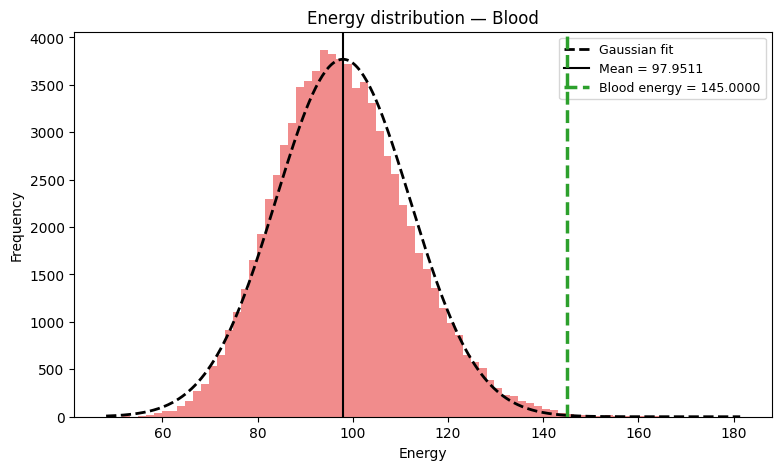

In [31]:
blood_energy_samples = energy_values_blood
blood_mean = np.mean(blood_energy_samples)
blood_median = np.median(blood_energy_samples)
blood_std = np.std(blood_energy_samples)
blood_min = np.min(blood_energy_samples)
blood_max = np.max(blood_energy_samples)

print(f"Blood energy samples: n={len(blood_energy_samples)}, mean={blood_mean:.6f}, median={blood_median:.6f}, std={blood_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(blood_energy_samples, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='lightcoral', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (blood_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - blood_mean) / blood_std) ** 2)
pdf_scaled = pdf * len(blood_energy_samples) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(blood_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {blood_mean:.4f}')

# Plot device energy for Blood (dotted line)
blood_val = device_energies.get('Blood')
plt.axvline(blood_val, color='tab:green', linestyle='--', linewidth=2.5, label=f"Blood energy = {blood_val:.4f}", zorder=9)
    

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Blood')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_blood.png', dpi=400, bbox_inches='tight')

plt.show()

Mitra energy samples: n=80000, mean=118.556317, median=117.707543, std=16.240742


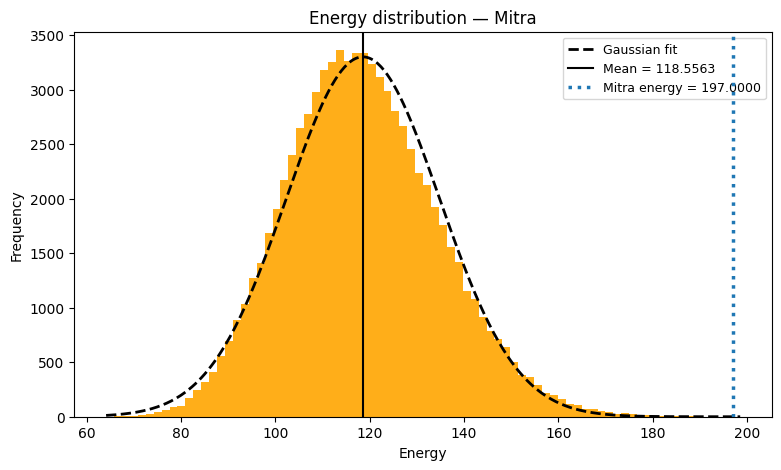

In [32]:
mitra_energy_samples = energy_values_mitra
mitra_mean = np.mean(mitra_energy_samples)
mitra_median = np.median(mitra_energy_samples)
mitra_std = np.std(mitra_energy_samples)
mitra_min = np.min(mitra_energy_samples)
mitra_max = np.max(mitra_energy_samples)

print(f"Mitra energy samples: n={len(mitra_energy_samples)}, mean={mitra_mean:.6f}, median={mitra_median:.6f}, std={mitra_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(mitra_energy_samples, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='orange', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (mitra_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - mitra_mean) / mitra_std) ** 2)
pdf_scaled = pdf * len(mitra_energy_samples) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(mitra_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {mitra_mean:.4f}')

# Plot device energy for Mitra (dotted line)
mitra_val = device_energies.get('Mitra')
plt.axvline(mitra_val, color='tab:blue', linestyle=':', linewidth=2.5, label=f"Mitra energy = {mitra_val:.4f}", zorder=9)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Mitra')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_mitra.png', dpi=400, bbox_inches='tight')

plt.show()

Plasma energy samples: n=80000, mean=106.544576, median=105.735807, std=14.966377


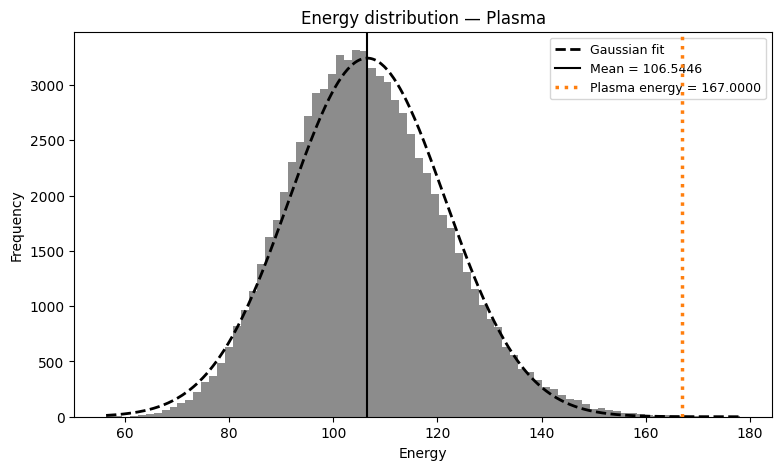

In [33]:
plasma_energy_samples = energy_values_plasma
plasma_mean = np.mean(plasma_energy_samples)
plasma_median = np.median(plasma_energy_samples)
plasma_std = np.std(plasma_energy_samples)
plasma_min = np.min(plasma_energy_samples)
plasma_max = np.max(plasma_energy_samples)

print(f"Plasma energy samples: n={len(plasma_energy_samples)}, mean={plasma_mean:.6f}, median={plasma_median:.6f}, std={plasma_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(plasma_energy_samples, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='gray', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (plasma_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - plasma_mean) / plasma_std) ** 2)
pdf_scaled = pdf * len(plasma_energy_samples) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(plasma_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {plasma_mean:.4f}')

# Plot device energy for Plasma (dotted line)
plasma_val = device_energies.get('Plasma')
plt.axvline(
    plasma_val, color='tab:orange', linestyle=':', 
    linewidth=2.5, label=f"Plasma energy = {plasma_val:.4f}", zorder=9)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Plasma')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_plasma.png', dpi=400, bbox_inches='tight')

plt.show()

Capitainer energy samples: n=80000, mean=112.517912, median=111.834235, std=15.612189


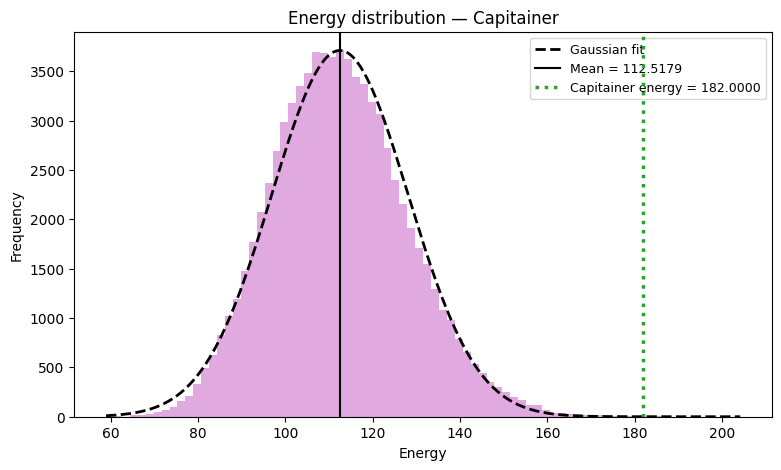

In [34]:
capitainer_energy_samples = energy_values_capitainer
capitainer_mean = np.mean(capitainer_energy_samples)
capitainer_median = np.median(capitainer_energy_samples)
capitainer_std = np.std(capitainer_energy_samples)
capitainer_min = np.min(capitainer_energy_samples)
capitainer_max = np.max(capitainer_energy_samples)

print(f"Capitainer energy samples: n={len(capitainer_energy_samples)}, mean={capitainer_mean:.6f}, median={capitainer_median:.6f}, std={capitainer_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(capitainer_energy_samples, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='plum', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (capitainer_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - capitainer_mean) / capitainer_std) ** 2)
pdf_scaled = pdf * len(capitainer_energy_samples) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(capitainer_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {capitainer_mean:.4f}')

# Plot device energy for Capitainer (dotted line)
capitainer_val = device_energies.get('Capitainer')
plt.axvline(
    capitainer_val, color='tab:green', linestyle=':', 
    linewidth=2.5, label=f"Capitainer energy = {capitainer_val:.4f}", zorder=9)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Capitainer')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_capitainer.png', dpi=400, bbox_inches='tight')

plt.show()

In [35]:
def plot_phase_diagram_for_graph(
    G,
    *,
    mu=1.0,
    gamma=1.0,
    kmax=20,
    scale_max=12,
    scale_steps=1,
    k_steps=1,
    cmap="magma",
    contour_color="white",
    title="Phase Diagram",
    show_transitions=True,
    transition_levels=8,
    highlight_scale=None,
    highlight_color="red",
    highlight_linewidth=2.0,
):
    H_obj = Hamiltonian(G)

    k_values, ratio, H = phase_diagram_values(
        Hamiltonian=H_obj,
        mu=float(mu),
        gamma=float(gamma),
        kmax=int(kmax),
        scale_max=float(scale_max),
        scale_steps=float(scale_steps),
        k_steps=int(k_steps),
    )

    # k_values, ratio, H are now numpy arrays
    # H shape: (len(k_values), len(scale_values))
    # ratio shape: (len(k_values), len(scale_values))
    
    scale_values = np.arange(0.25, scale_max + scale_steps, scale_steps)
    
    # Compute extent: [left, right, bottom, top]
    scale_min = scale_values[0]
    scale_max_val = scale_values[-1]
    k_min = k_values[0]
    k_max = k_values[-1]
    extent = [scale_min, scale_max_val, k_min, k_max]

    fig, ax = plt.subplots(figsize=(9, 5), constrained_layout=True)
    im = ax.imshow(
        H,
        aspect="auto",
        origin="lower",
        interpolation="bilinear",
        cmap=cmap,
        extent=extent,
    )

    # Add transition boundaries (contour lines)
    if show_transitions:
        h_min, h_max = np.nanmin(H), np.nanmax(H)
        contour_levels = np.linspace(h_min, h_max, transition_levels)
        cs = ax.contour(
            scale_values,
            k_values,
            H,
            levels=contour_levels,
            colors=contour_color,
            linewidths=0.7,
            alpha=0.5,
        )
        ax.clabel(cs, inline=True, fontsize=7, fmt="%.3f")

    # Add vertical line at specific mu/gamma value
    if highlight_scale is not None:
        ax.axvline(
            x=float(highlight_scale),
            color=highlight_color,
            linestyle="--",
            linewidth=highlight_linewidth,
            alpha=0.8,
            label=f"s = {highlight_scale:.3f}",
        )
        ax.legend(loc="upper right")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(r"$H \approx 0$")
    ax.set_xlabel(r"$s$")
    ax.set_ylabel(r"$k$")
    ax.set_title(title)

    print(f"Graph: n={G.number_of_nodes()}, m={G.number_of_edges()}")
    print("Computed phase diagram.")
    if show_transitions:
        print(f"Transition boundaries shown at {transition_levels} levels.")
    if highlight_scale is not None:
        print(f"Highlighted transition line at μ/γ = {highlight_scale:.3f}")

    figures_dir = project_root / "examples/figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    filename = f"PD_{title}.png"
    plt.savefig(figures_dir / filename, dpi=300)
    plt.show()

    return fig, ax, (k_values, ratio, H)

Intersection energy samples: n=80000, mean=84.356923, median=83.664936, std=12.623728


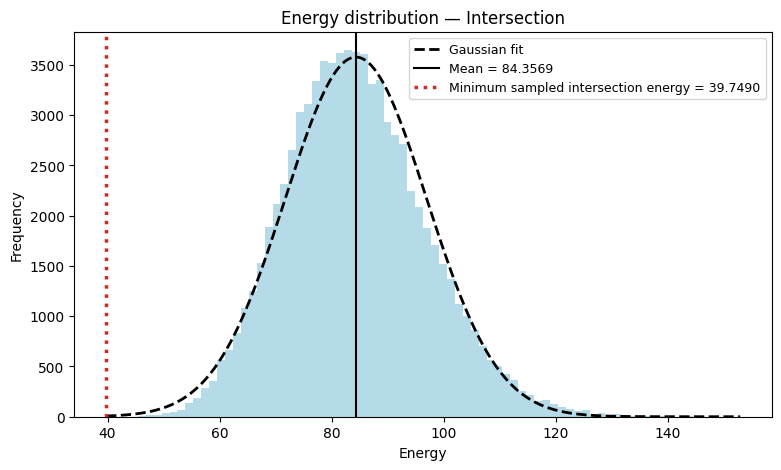

In [36]:
intersection_energy_samples = energy_values_intersection
intersection_mean = np.mean(intersection_energy_samples)
intersection_median = np.median(intersection_energy_samples)
intersection_std = np.std(intersection_energy_samples)
intersection_min = np.min(intersection_energy_samples)
intersection_max = np.max(intersection_energy_samples)

print(f"Intersection energy samples: n={len(intersection_energy_samples)}, mean={intersection_mean:.6f}, median={intersection_median:.6f}, std={intersection_std:.6f}")

# Histogram and Gaussian overlay
counts, bins = np.histogram(intersection_energy_samples, bins=80)
bin_width = bins[1] - bins[0]
bin_centers = (bins[:-1] + bins[1:]) / 2
max_count = counts.max() if len(counts)>0 else 1

plt.figure(figsize=(9,5))
plt.bar(bin_centers, counts, width=bin_width, color='lightblue', edgecolor='none', alpha=0.9)

# Gaussian fit (scaled to histogram)
x = np.linspace(bins[0], bins[-1], 400)
pdf = (1.0 / (intersection_std * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x - intersection_mean) / intersection_std) ** 2)
pdf_scaled = pdf * len(intersection_energy_samples) * bin_width
plt.plot(x, pdf_scaled, color='k', linestyle='--', linewidth=2, label='Gaussian fit')

# Annotate summary stats
plt.axvline(intersection_mean, color='black', linestyle='-', linewidth=1.5, label=f'Mean = {intersection_mean:.4f}')

# Plot a reference value from the sampled minimum-energy subset
reference_intersection_energy = H.energy(min_energy_intersection, mu=mu, gamma=gamma)
plt.axvline(
    reference_intersection_energy, color='tab:red', linestyle=':', 
    linewidth=2.5, label=f"Minimum sampled intersection energy = {reference_intersection_energy:.4f}", zorder=9)

plt.xlabel('Energy')
plt.ylabel('Frequency')
plt.title('Energy distribution — Intersection')
plt.legend(loc='upper right', fontsize=9)
plt.grid(False)

out_dir = data_folder / 'figs'
plt.savefig(out_dir / 'energy_distribution_intersection.png', dpi=400, bbox_inches='tight')

plt.show()